In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path 
import pickle
from src.feature_generation import pool_features
import numpy as np

encoder_name = "perch2"
dir = Path("/idiap/temp/adeych/data")
X_bags_dir = "perch2-bags.pkl"
with open(dir / "feature_banks" / X_bags_dir, "rb") as f:
    X_bags = pickle.load(f)
X_bags_pooled = pool_features(X_bags, windows=False,window_pooled=False,encoder = encoder_name)
y = np.load(dir / "feature_banks" / "labels.npy")

/idiap/temp/adeych/conda/envs/temp-env-4/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
X_bags_mean = pool_features(X_bags_pooled,windows = True, encoder = encoder_name)

In [12]:
from src.linear_probe import linear_probe_tuned_optuna
results_linear_probe = linear_probe_tuned_optuna(
       X_bags_mean, y, n_split_out=2, n_split_in=2, num_trials=1,
       n_optuna_trials=2, n_epochs_max=40, random_state=43,
)

/idiap/temp/adeych/conda/envs/temp-env-4/lib/python3.12/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-08-24 12:12:41,686] A new study created in memory with name: LinearProbe_trial0_fold0


Starting Trial 1/1 with random_state=43...
  Tuning and evaluating model: LinearProbe
    Evaluating fold 1/2


[I 2026-08-24 12:12:42,723] Trial 0 finished with value: 0.8147673993809401 and parameters: {'learning_rate': 0.0005946850022952478, 'weight_decay': 0.0027851491832011333, 'batch_size': 8}. Best is trial 0 with value: 0.8147673993809401.


39
0.8148865860142538


[I 2026-08-24 12:12:44,151] Trial 1 finished with value: 0.8337475576129729 and parameters: {'learning_rate': 0.0001307359649102226, 'weight_decay': 0.00010465249834111978, 'batch_size': 4}. Best is trial 1 with value: 0.8337475576129729.


...

    Evaluating fold 2/2


[I 2026-08-24 12:12:46,183] Trial 0 finished with value: 0.8030603346075874 and parameters: {'learning_rate': 3.846061711976175e-05, 'weight_decay': 0.002591258907511775, 'batch_size': 8}. Best is trial 0 with value: 0.8030603346075874.


39
0.8052950085701223


[I 2026-08-24 12:12:47,159] Trial 1 finished with value: 0.8711589394944241 and parameters: {'learning_rate': 0.0007477158825701279, 'weight_decay': 0.0006309739400711668, 'batch_size': 8}. Best is trial 1 with value: 0.8711589394944241.


12
0.8834558159463198


In [14]:
from src.mil_bioacoustics_temporal import abmil_classifier_tuned_optuna

results = abmil_classifier_tuned_optuna(X_bags_pooled, y, n_split_out=2, n_split_in=2, num_trials=1,
                                   random_state=43, n_optuna_trials=2, n_epochs_max=5,
                                   variants=('ABMIL_LSTM',))

[I 2026-08-24 12:14:17,077] A new study created in memory with name: ABMIL_LSTM_trial0_fold0


Starting Trial 1/1 with random_state=43...
  Tuning and evaluating model: ABMIL_LSTM
    Evaluating fold 1/2
Start inner loop)
Inner loop number 1
Inner loop number 2


[I 2026-08-24 12:14:21,315] Trial 0 finished with value: 0.6630928052784043 and parameters: {'hidden_dim': 32, 'dropout': 0.20988698815802495, 'learning_rate': 0.0001307359649102226, 'weight_decay': 0.00010465249834111978, 'batch_size': 4, 'attention_dim': 64}. Best is trial 0 with value: 0.6630928052784043.


End inner loop)
5
0.6630928052784043
Start inner loop)
Inner loop number 1
Inner loop number 2


[I 2026-08-24 12:14:25,444] Trial 1 finished with value: 0.8205115274602979 and parameters: {'hidden_dim': 64, 'dropout': 0.28153435374670455, 'learning_rate': 0.0008098074948178855, 'weight_decay': 0.00017847136051161845, 'batch_size': 16, 'attention_dim': 16}. Best is trial 1 with value: 0.8205115274602979.


...

    Evaluating fold 2/2
Start inner loop)
Inner loop number 1
Inner loop number 2


[I 2026-08-24 12:14:32,686] Trial 0 finished with value: 0.9046058994990192 and parameters: {'hidden_dim': 64, 'dropout': 0.18070412623680387, 'learning_rate': 0.0007477158825701279, 'weight_decay': 0.0006309739400711668, 'batch_size': 8, 'attention_dim': 32}. Best is trial 0 with value: 0.9046058994990192.


End inner loop)
5
0.9046058994990192
Start inner loop)
Inner loop number 1
Inner loop number 2


[I 2026-08-24 12:14:36,912] Trial 1 finished with value: 0.861865044537379 and parameters: {'hidden_dim': 128, 'dropout': 0.45422745189688474, 'learning_rate': 0.00012609535237318305, 'weight_decay': 1.0264144848605467e-05, 'batch_size': 4, 'attention_dim': 32}. Best is trial 0 with value: 0.9046058994990192.


End inner loop)
5
0.861865044537379


In [13]:
from src.mil_bioacoustics_temporal import abmil_classifier_tuned_optuna

results = abmil_classifier_tuned_optuna(X_bags_pooled, y, n_split_out=5, n_split_in=5, num_trials=1,
                                   random_state=43, n_optuna_trials=5, n_epochs_max=40,
                                   variants=('ABMIL_LSTM',))

[I 2026-08-21 18:52:46,751] A new study created in memory with name: ABMIL_LSTM_trial0_fold0


Starting Trial 1/1 with random_state=43...
  Tuning and evaluating model: ABMIL_LSTM
    Evaluating fold 1/5
Start inner loop)
Inner loop number 1
Inner loop number 2
Inner loop number 3
Inner loop number 4
Inner loop number 5


[I 2026-08-21 18:55:49,071] Trial 0 finished with value: 0.9201212972329349 and parameters: {'hidden_dim': 32, 'dropout': 0.20988698815802495, 'learning_rate': 0.0001307359649102226, 'weight_decay': 0.00010465249834111978, 'batch_size': 4, 'attention_dim': 64}. Best is trial 0 with value: 0.9201212972329349.


End inner loop)
37
0.9169383408762822
Start inner loop)
Inner loop number 1


[W 2026-08-21 18:56:15,680] Trial 1 failed with parameters: {'hidden_dim': 64, 'dropout': 0.28153435374670455, 'learning_rate': 0.0008098074948178855, 'weight_decay': 0.00017847136051161845, 'batch_size': 16, 'attention_dim': 16} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/idiap/temp/adeych/conda/envs/temp-env-4/lib/python3.12/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/remote/idiap.svm/home.active/adeych/bat-project/src/mil_bioacoustics_temporal.py", line 16, in objective
    replaces the pre-LSTM representation.
  File "/remote/idiap.svm/home.active/adeych/bat-project/src/mil_bioacoustics_temporal.py", line 490, in train_abmil
    logits, _ = model(X_bag)
                ^^^^^^^^^^^^
  File "/idiap/temp/adeych/conda/envs/temp-env-4/lib/python3.12/site-packages/torch/nn/modules/module.py", line 1778, in _wrapped_call_impl
    return se

KeyboardInterrupt: 

In [23]:

results = abmil_classifier_tuned_optuna(X_bags_pooled, y, n_split_out=2, n_split_in=2, num_trials=1,
                                   random_state=43, n_optuna_trials=2, n_epochs_max=5,
                                   variants=('LSTM_only',))

[I 2026-08-21 19:02:20,749] A new study created in memory with name: LSTM_only_trial0_fold0


Starting Trial 1/1 with random_state=43...
  Tuning and evaluating model: LSTM_only
    Evaluating fold 1/2
Start inner loop)
Inner loop number 1
Inner loop number 2


[I 2026-08-21 19:02:22,583] Trial 0 finished with value: 0.7099009152775316 and parameters: {'hidden_dim': 32, 'dropout': 0.20988698815802495, 'learning_rate': 0.0001307359649102226, 'weight_decay': 0.00010465249834111978, 'batch_size': 4}. Best is trial 0 with value: 0.7099009152775316.


End inner loop)
4
0.7026474606956694
Start inner loop)
Inner loop number 1
Inner loop number 2


[I 2026-08-21 19:02:24,302] Trial 1 finished with value: 0.7390284815380171 and parameters: {'hidden_dim': 128, 'dropout': 0.2387926911083839, 'learning_rate': 0.00010083292952534698, 'weight_decay': 3.011485676801149e-05, 'batch_size': 16}. Best is trial 1 with value: 0.7390284815380171.


...

    Evaluating fold 2/2
Start inner loop)
Inner loop number 1
Inner loop number 2


[I 2026-08-21 19:02:27,174] Trial 0 finished with value: 0.8497989312925602 and parameters: {'hidden_dim': 64, 'dropout': 0.18070412623680387, 'learning_rate': 0.0007477158825701279, 'weight_decay': 0.0006309739400711668, 'batch_size': 8}. Best is trial 0 with value: 0.8497989312925602.


End inner loop)
3
0.848897513302691
Start inner loop)
Inner loop number 1
Inner loop number 2


[I 2026-08-21 19:02:28,914] Trial 1 finished with value: 0.7351265238337903 and parameters: {'hidden_dim': 64, 'dropout': 0.2514009676192669, 'learning_rate': 5.047170480042051e-05, 'weight_decay': 0.0004768906243761117, 'batch_size': 8}. Best is trial 0 with value: 0.8497989312925602.


End inner loop)
5
0.7351265238337903
3


In [24]:
print(results)

[{'trial': 0, 'model': 'LSTM_only', 'best_models': [ABMILSklearnWrapper(batch_size=16, dropout=0.2387926911083839, hidden_dim=128,
                    learning_rate=0.00010083292952534698,
                    lstm_bidirectional=False, lstm_residual=True, n_epochs=5,
                    pooling='mean', random_state=43, use_lstm=True,
                    weight_decay=3.011485676801149e-05), ABMILSklearnWrapper(batch_size=8, dropout=0.18070412623680387, hidden_dim=64,
                    learning_rate=0.0007477158825701279,
                    lstm_bidirectional=False, lstm_residual=True, n_epochs=3,
                    pooling='mean', random_state=43, use_lstm=True,
                    weight_decay=0.0006309739400711668)], 'mean_AP': np.float64(0.8224966731937692), 'std_AP': np.float64(0.03857055979775927), 'y_true_cv': [array([[0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 

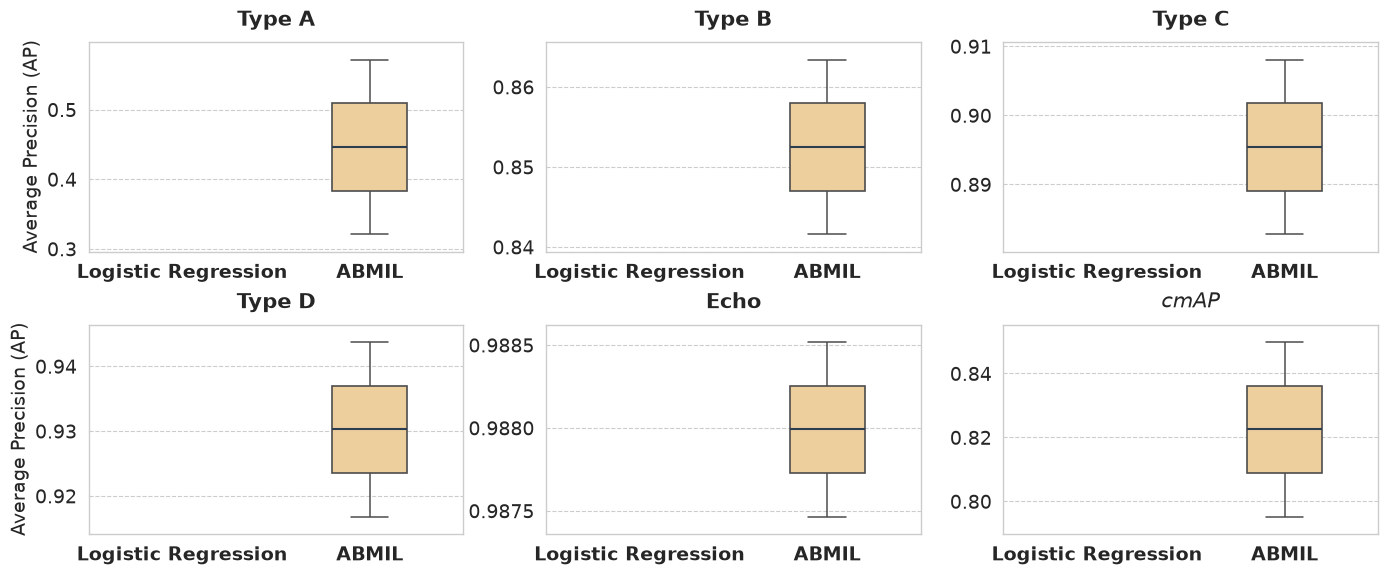

In [25]:
from src.metrics import plot_abmil_vs_perch_boxplots

plot_abmil_vs_perch_boxplots(results, results, label_names=None)